<a href="https://colab.research.google.com/github/FasikuChristian/QSAR-Modeling-Pipeline-for-Serine-Threonine-Kinase-1/blob/main/modified_CDD_ML_Part_4_AKT.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Bioinformatics Project - Computational Drug Discovery [Part 4] Regression Models with Random Forest**



---

## **1. Import libraries**

In [ ]:
import pandas as pd
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


## **2. Load the data set**

In [ ]:
df = pd.read_csv('/content/drive/MyDrive/Colab Notebooks/QSAR MODELLING CODES/AKT1/AKT_06_bioactivity_data_3class_pIC50_pubchem_fp.csv')
df

,PubchemFP0,PubchemFP1,PubchemFP2,PubchemFP3,PubchemFP4,PubchemFP5,PubchemFP6,PubchemFP7,PubchemFP8,PubchemFP9,...,PubchemFP872,PubchemFP873,PubchemFP874,PubchemFP875,PubchemFP876,PubchemFP877,PubchemFP878,PubchemFP879,PubchemFP880,pIC50
0,1,1,1,0,0,0,0,0,0,1,...,0,0,0,0,0,0,0,0,0,4.698970
1,1,1,1,0,0,0,0,0,0,1,...,0,0,0,0,0,0,0,0,0,4.698970
2,1,1,1,0,0,0,0,0,0,1,...,0,0,0,0,0,0,0,0,0,6.000000
3,1,1,1,0,0,0,0,0,0,1,...,0,0,0,0,0,0,0,0,0,6.000000
4,1,1,1,1,0,0,0,0,0,1,...,0,0,0,0,0,0,0,0,0,5.823909
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
150,1,1,1,0,0,0,0,0,0,1,...,0,0,0,0,0,0,0,0,0,5.000000
151,1,1,1,0,0,0,0,0,0,1,...,0,0,0,0,0,0,0,0,0,5.547462
152,1,1,1,0,0,0,0,0,0,1,...,0,0,0,0,0,0,0,0,0,5.489871
153,1,1,1,0,0,0,0,0,0,1,...,0,0,0,0,0,0,0,0,0,5.000000


In [ ]:
df2 = pd.read_csv('/content/drive/MyDrive/Colab Notebooks/QSAR MODELLING CODES/AKT1/AKT1_04_bioactivity_data_3class_pIC50_all.csv')
df2 = df2.drop('molecule_chembl_id' , axis=1)
df2


,Unnamed: 0,canonical_smiles,class,MW,LogP,NumHDonors,NumHAcceptors,pIC50
0,0,COc1cc2c(Nc3ccc(Br)cc3F)ncnc2cc1OCCn1ccnn1,inactive,459.279,3.95410,1.0,8.0,4.698970
1,1,COc1cc2c(Nc3ccc(Br)cc3F)ncnc2cc1OCC1CCN(C)CC1.Cl,inactive,475.362,5.00420,1.0,6.0,4.698970
2,2,COc1cc2c(Nc3ccc(Oc4ccccc4)cc3)c(C#N)cnc2cc1OCC...,active,510.594,5.75208,1.0,8.0,6.000000
3,3,COc1cc2c(Nc3ccc(Sc4nccn4C)c(Cl)c3)c(C#N)cnc2cc...,active,565.099,5.49788,1.0,10.0,6.000000
4,4,CCCCCCCCCCCCCCCCCCOC[C@H](COP(=O)(O)O[C@H]1[C@...,intermediate,584.728,4.62900,5.0,9.0,5.823909
...,...,...,...,...,...,...,...,...
150,150,CCCCCCCCCCCCc1ccc(S(=O)(=O)Nc2nncs2)cc1,inactive,409.621,5.80230,1.0,5.0,5.000000
151,151,CC[n+]1c(/C=C/N(C)c2ccccc2)n(-c2ccccc2)c2ccc(-...,intermediate,487.652,7.32170,0.0,4.0,5.547462
152,152,Cc1n[nH]c2ccc(-c3cncc(OC[C@@H](N)Cc4ccccc4)c3)...,intermediate,358.445,3.88212,2.0,4.0,5.489871
153,153,CCn1c(-c2nonc2N)nc2c(C#CC(C)(C)O)ncc(OC[C@H]3C...,inactive,425.493,1.58420,3.0,10.0,5.000000


In [ ]:
import pandas as pd

# Concatenate df and df2 column-wise
df_merged = pd.concat([df, df2], axis = 1)

# Check the result
print(df_merged.shape)
print(df_merged.head())

(155, 890)
   PubchemFP0  PubchemFP1  PubchemFP2  PubchemFP3  PubchemFP4  PubchemFP5  \
0           1           1           1           0           0           0   
1           1           1           1           0           0           0   
2           1           1           1           0           0           0   
3           1           1           1           0           0           0   
4           1           1           1           1           0           0   

   PubchemFP6  PubchemFP7  PubchemFP8  PubchemFP9  ...  PubchemFP880  \
0           0           0           0           1  ...             0   
1           0           0           0           1  ...             0   
2           0           0           0           1  ...             0   
3           0           0           0           1  ...             0   
4           0           0           0           1  ...             0   

      pIC50  Unnamed: 0                                   canonical_smiles  \
0  4.698970    

In [ ]:
removed_selection = ['canonical_smiles', 'class' ]


In [ ]:
df = df_merged.drop(removed_selection, axis=1)
df

,PubchemFP0,PubchemFP1,PubchemFP2,PubchemFP3,PubchemFP4,PubchemFP5,PubchemFP6,PubchemFP7,PubchemFP8,PubchemFP9,...,PubchemFP878,PubchemFP879,PubchemFP880,pIC50,Unnamed: 0,MW,LogP,NumHDonors,NumHAcceptors,pIC50
0,1,1,1,0,0,0,0,0,0,1,...,0,0,0,4.698970,0,459.279,3.95410,1.0,8.0,4.698970
1,1,1,1,0,0,0,0,0,0,1,...,0,0,0,4.698970,1,475.362,5.00420,1.0,6.0,4.698970
2,1,1,1,0,0,0,0,0,0,1,...,0,0,0,6.000000,2,510.594,5.75208,1.0,8.0,6.000000
3,1,1,1,0,0,0,0,0,0,1,...,0,0,0,6.000000,3,565.099,5.49788,1.0,10.0,6.000000
4,1,1,1,1,0,0,0,0,0,1,...,0,0,0,5.823909,4,584.728,4.62900,5.0,9.0,5.823909
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
150,1,1,1,0,0,0,0,0,0,1,...,0,0,0,5.000000,150,409.621,5.80230,1.0,5.0,5.000000
151,1,1,1,0,0,0,0,0,0,1,...,0,0,0,5.547462,151,487.652,7.32170,0.0,4.0,5.547462
152,1,1,1,0,0,0,0,0,0,1,...,0,0,0,5.489871,152,358.445,3.88212,2.0,4.0,5.489871
153,1,1,1,0,0,0,0,0,0,1,...,0,0,0,5.000000,153,425.493,1.58420,3.0,10.0,5.000000


In [ ]:
df.to_csv('AKT_06_bioactivity_Molecular Descriptors_and_Molecular Fingerprints_fp_merged_.csv', index=False)
import os

dest_dir = "/content/drive/MyDrive/Colab Notebooks/QSAR MODELLING CODES/AKT1"

# Copy file
! cp "AKT_06_bioactivity_Molecular Descriptors_and_Molecular Fingerprints_fp_merged_.csv" "{dest_dir}"

In [ ]:
# import file
df = pd.read_csv('/content/drive/MyDrive/Colab Notebooks/QSAR MODELLING CODES/AKT1/AKT_06_bioactivity_Molecular Descriptors_and_Molecular Fingerprints_fp_merged_.csv')
df

,PubchemFP0,PubchemFP1,PubchemFP2,PubchemFP3,PubchemFP4,PubchemFP5,PubchemFP6,PubchemFP7,PubchemFP8,PubchemFP9,...,PubchemFP878,PubchemFP879,PubchemFP880,pIC50,Unnamed: 0,MW,LogP,NumHDonors,NumHAcceptors,pIC50.1
0,1,1,1,0,0,0,0,0,0,1,...,0,0,0,4.698970,0,459.279,3.95410,1.0,8.0,4.698970
1,1,1,1,0,0,0,0,0,0,1,...,0,0,0,4.698970,1,475.362,5.00420,1.0,6.0,4.698970
2,1,1,1,0,0,0,0,0,0,1,...,0,0,0,6.000000,2,510.594,5.75208,1.0,8.0,6.000000
3,1,1,1,0,0,0,0,0,0,1,...,0,0,0,6.000000,3,565.099,5.49788,1.0,10.0,6.000000
4,1,1,1,1,0,0,0,0,0,1,...,0,0,0,5.823909,4,584.728,4.62900,5.0,9.0,5.823909
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
150,1,1,1,0,0,0,0,0,0,1,...,0,0,0,5.000000,150,409.621,5.80230,1.0,5.0,5.000000
151,1,1,1,0,0,0,0,0,0,1,...,0,0,0,5.547462,151,487.652,7.32170,0.0,4.0,5.547462
152,1,1,1,0,0,0,0,0,0,1,...,0,0,0,5.489871,152,358.445,3.88212,2.0,4.0,5.489871
153,1,1,1,0,0,0,0,0,0,1,...,0,0,0,5.000000,153,425.493,1.58420,3.0,10.0,5.000000


## **3. Input features**
The ***AKT*** data set contains 881 input features and 1 output variable (pIC50 values).

### **3.1. Input features**

In [ ]:
X = df.drop('pIC50', axis=1)

In [ ]:


corr_matrix = X.corr().abs()

# Select upper triangle of correlation matrix to avoid duplicates
upper_tri = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))

# Find features with correlation greater than 0.95
to_drop = [column for column in upper_tri.columns if any(upper_tri[column] > 0.90)]

# Drop identified features from X
X = X.drop(to_drop, axis=1)

print(f"Number of features after removing highly correlated features: {X.shape[1]}")

Number of features after removing highly correlated features: 602


### **3.2. Output features**

In [ ]:
Y = df.pIC50
Y

,pIC50
0,4.698970
1,4.698970
2,6.000000
3,6.000000
4,5.823909
...,...
150,5.000000
151,5.547462
152,5.489871
153,5.000000


### **3.3. Let's examine the data dimension**

In [ ]:
X.shape

(155, 602)

In [ ]:
Y.shape

(155,)

### **3.4. Remove low variance features**

In [ ]:
from sklearn.feature_selection import VarianceThreshold
selection = VarianceThreshold(threshold=(.8 * (1 - .8)))
X = selection.fit_transform(X)

In [ ]:
X.shape

(155, 78)

## **4. Data split (80/20 ratio)**

In [ ]:
X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.2, random_state=42)

In [ ]:
X_train.shape, Y_train.shape

((124, 78), (124,))

In [ ]:
X_test.shape, Y_test.shape

((31, 78), (31,))

## **5. Building a Regression Model using Random Forest**

In [ ]:
from sklearn.model_selection import cross_val_score
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import numpy as np

model = RandomForestRegressor(random_state=42, max_depth=10, n_estimators=100)
model.fit(X_train, Y_train)
Y_pred_rf = model.predict(X_test)

r2_rf = r2_score(Y_test, Y_pred_rf)
rmse_rf = mean_squared_error (Y_test, Y_pred_rf)
mae_rf = mean_absolute_error(Y_test, Y_pred_rf)

print(" R-squared:", r2_rf)
print(" RMSE:", rmse_rf)
print(" Forest MAE:", mae_rf)
scores = cross_val_score(model, X, Y, cv=5, scoring='r2')
print("Mean CV R²:", np.mean(scores))
print("Std CV R²:", np.std(scores))

 R-squared: 0.9992390405756989
 RMSE: 0.001627400093351081
 Forest MAE: 0.0295386890680111
Mean CV R²: 0.9871918461685301
Std CV R²: 0.016093501563509662


 R-squared: 0.9992390405756989
 RMSE: 0.001627400093351081
 Forest MAE: 0.0295386890680111


In [ ]:
Y_pred_rf

array([8.54736573, 5.00059092, 5.28556061, 5.74953685, 6.12981994,
       7.69710836, 8.98884145, 6.66291518, 5.0009572 , 8.96726506,
       5.32030749, 4.99400456, 7.15920521, 8.89181049, 5.82122367,
       7.68400771, 5.79151012, 4.99726999, 5.76898525, 4.99245539,
       6.0678541 , 5.28146043, 4.97454184, 4.42131244, 8.38333068,
       6.59657203, 8.53251745, 6.40038502, 5.63100741, 8.53314844,
       4.45587   ])

## **6. Scatter Plot of Experimental vs Predicted pIC50 Values**

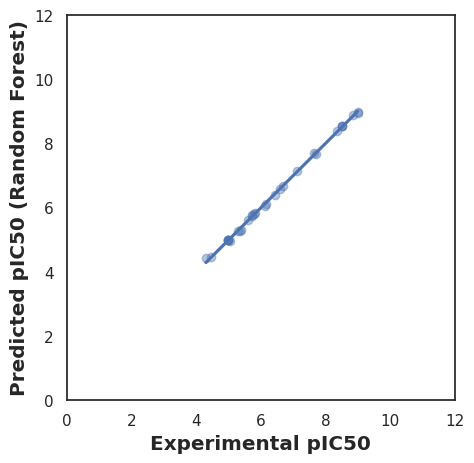

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.set(color_codes=True)
sns.set_style("white")

ax = sns.regplot(x=Y_test, y=Y_pred_rf, scatter_kws={'alpha':0.4})
ax.set_xlabel('Experimental pIC50', fontsize='large', fontweight='bold')
ax.set_ylabel('Predicted pIC50 (Random Forest)', fontsize='large', fontweight='bold')
ax.set_xlim(0, 12)
ax.set_ylim(0, 12)
ax.figure.set_size_inches(5, 5)
plt.show()

## **7. Building a Regression Model using Gradient Boosting Regressor (GBR)**

GBR R-squared: 0.9995238095109663
GBR RMSE: 0.0010183886572114544
GBR MAE: 0.018265944875494194
Mean CV R²: 0.9926154716981351
Std CV R²: 0.011179210796177038


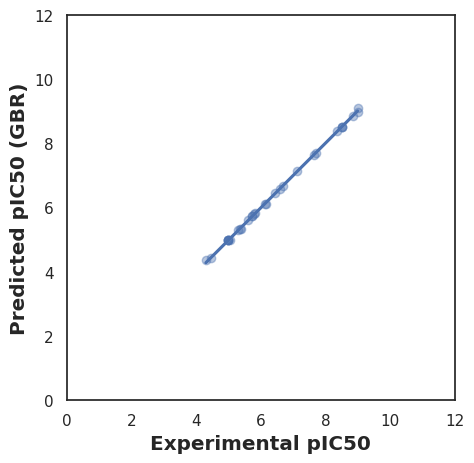

In [ ]:
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

gbr_model = GradientBoostingRegressor(n_estimators=500, learning_rate=0.05, max_depth=4, random_state=0)
gbr_model.fit(X_train, Y_train)

Y_pred_gbr = gbr_model.predict(X_test)

r2_gbr = gbr_model.score(X_test, Y_test)
rmse_gbr = mean_squared_error(Y_test, Y_pred_gbr)
mae_gbr = mean_absolute_error(Y_test, Y_pred_gbr)

print("GBR R-squared:", r2_gbr)
print("GBR RMSE:", rmse_gbr)
print("GBR MAE:", mae_gbr)
scores = cross_val_score(gbr_model, X, Y, cv=5, scoring='r2')
print("Mean CV R²:", np.mean(scores))
print("Std CV R²:", np.std(scores))

sns.set(color_codes=True)
sns.set_style("white")

ax_gbr = sns.regplot(x=Y_test, y=Y_pred_gbr, scatter_kws={'alpha':0.4})
ax_gbr.set_xlabel('Experimental pIC50', fontsize='large', fontweight='bold')
ax_gbr.set_ylabel('Predicted pIC50 (GBR)', fontsize='large', fontweight='bold')
ax_gbr.set_xlim(0, 12)
ax_gbr.set_ylim(0, 12)
ax_gbr.figure.set_size_inches(5, 5)
plt.show()

## **8. Building a Regression Model using XGBoost**

[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000136 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 309
[LightGBM] [Info] Number of data points in the train set: 124, number of used features: 78
[LightGBM] [Info] Start training from score 6.291632
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -i

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(


[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No f

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(


[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000281 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 298
[LightGBM] [Info] Number of data points in the train set: 124, number of used features: 76
[LightGBM] [Info] Start training from score 6.284573
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -i

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(


[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000153 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 303
[LightGBM] [Info] Number of data points in the train set: 124, number of used features: 78
[LightGBM] [Info] Start training from score 5.927734
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -i

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(


Mean CV R²: 0.8922358051107171
Std CV R²: 0.10303771098959781
LightGBM R-squared: 0.9728436578237794
LightGBM RMSE: 0.05807699120521227
LightGBM MAE: 0.17771551512889527


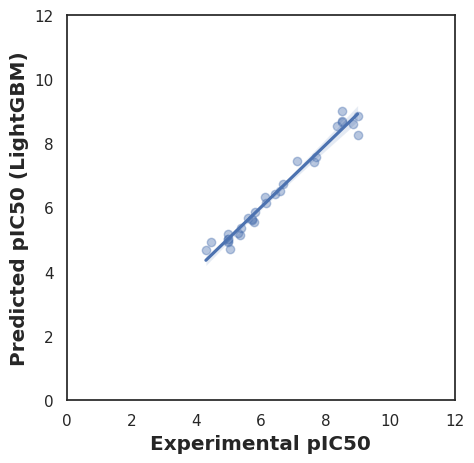

In [ ]:
import lightgbm as lgb
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

lgb_model = lgb.LGBMRegressor(n_estimators=500, learning_rate=0.05, max_depth=4, random_state=0)
lgb_model.fit(X_train, Y_train)

Y_pred_lgb = lgb_model.predict(X_test)

r2_lgb = lgb_model.score(X_test, Y_test)
rmse_lgb = mean_squared_error(Y_test, Y_pred_lgb)
mae_lgb = mean_absolute_error(Y_test, Y_pred_lgb)
scores = cross_val_score(lgb_model, X, Y, cv=5, scoring='r2')
print("Mean CV R²:", np.mean(scores))
print("Std CV R²:", np.std(scores))

print("LightGBM R-squared:", r2_lgb)
print("LightGBM RMSE:", rmse_lgb)
print("LightGBM MAE:", mae_lgb)

sns.set(color_codes=True)
sns.set_style("white")

ax_lgb = sns.regplot(x=Y_test, y=Y_pred_lgb, scatter_kws={'alpha':0.4})
ax_lgb.set_xlabel('Experimental pIC50', fontsize='large', fontweight='bold')
ax_lgb.set_ylabel('Predicted pIC50 (LightGBM)', fontsize='large', fontweight='bold')
ax_lgb.set_xlim(0, 12)
ax_lgb.set_ylim(0, 12)
ax_lgb.figure.set_size_inches(5, 5)
plt.show()

## **10. Building a Regression Model using CatBoost**

In [ ]:
from catboost import CatBoostRegressor, cv, Pool
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error

# Split data (this was moved here to ensure X_train and Y_train are consistent for all models)
X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.2, random_state=42)

# Initialize CatBoost
model_cb = CatBoostRegressor(
    iterations=1000,
    depth=6,
    learning_rate=0.05,
    loss_function='RMSE',
    verbose=0
)

# Fit
model_cb.fit(X_train, Y_train)

# Predict on test set
y_pred_cb = model_cb.predict(X_test)

# Compute metrics
r2_cb = r2_score(Y_test, y_pred_cb)
rmse_cb = mean_squared_error(Y_test, y_pred_cb)
mae_cb = mean_absolute_error(Y_test, y_pred_cb)
score = cross_val_score(model_cb, X, Y, cv=5, scoring='r2')
print("Mean CV R²:", np.mean(scores))
print("Std CV R²:", np.std(scores))

print("CatBoost R-squared:", r2_cb)
print("CatBoost RMSE:", rmse_cb)
print("CatBoost MAE:", mae_cb)

Mean CV R²: 0.8922358051107171
Std CV R²: 0.10303771098959781
CatBoost R-squared: 0.9783499796828938
CatBoost RMSE: 0.046301082501834484
CatBoost MAE: 0.13447581981951917


KNN R-squared: 0.653582162846548
KNN RMSE: 0.7408547716454512
KNN MAE: 0.6260931252019155
Mean CV R²: 0.8922358051107171
Std CV R²: 0.10303771098959781


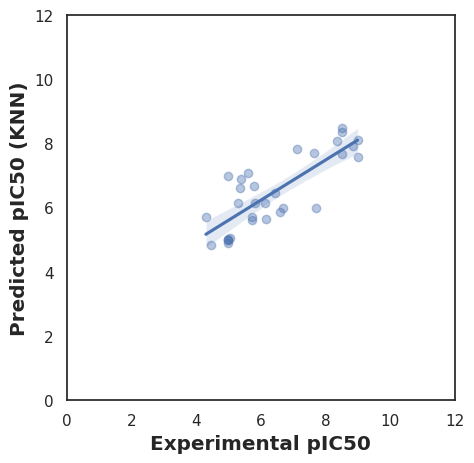

In [ ]:
from sklearn.neighbors import KNeighborsRegressor
from sklearn.model_selection import cross_val_score

knn_model = KNeighborsRegressor(n_neighbors=5)
knn_model.fit(X_train, Y_train)

Y_pred_knn = knn_model.predict(X_test)

r2_knn = knn_model.score(X_test, Y_test)
rmse_knn = mean_squared_error(Y_test, Y_pred_knn)
mae_knn = mean_absolute_error(Y_test, Y_pred_knn)

print("KNN R-squared:", r2_knn)
print("KNN RMSE:", rmse_knn)
print("KNN MAE:", mae_knn)

sns.set(color_codes=True)
sns.set_style("white")
score = cross_val_score(knn_model, X, Y, cv=5, scoring='r2')
print("Mean CV R²:", np.mean(scores))
print("Std CV R²:", np.std(scores))


ax_knn = sns.regplot(x=Y_test, y=Y_pred_knn, scatter_kws={'alpha':0.4})
ax_knn.set_xlabel('Experimental pIC50', fontsize='large', fontweight='bold')
ax_knn.set_ylabel('Predicted pIC50 (KNN)', fontsize='large', fontweight='bold')
ax_knn.set_xlim(0, 12)
ax_knn.set_ylim(0, 12)
ax_knn.figure.set_size_inches(5, 5)
plt.show()

## **12. Comparison of Regression Models**

,Model,R-squared,RMSE,MAE
0,Gradient Boosting,0.999524,0.001018,0.018266
1,Random Forest,0.999239,0.001627,0.029539
2,CatBoost,0.978350,0.046301,0.134476
3,LightGBM,0.972844,0.058077,0.177716
4,KNN,0.653582,0.740855,0.626093


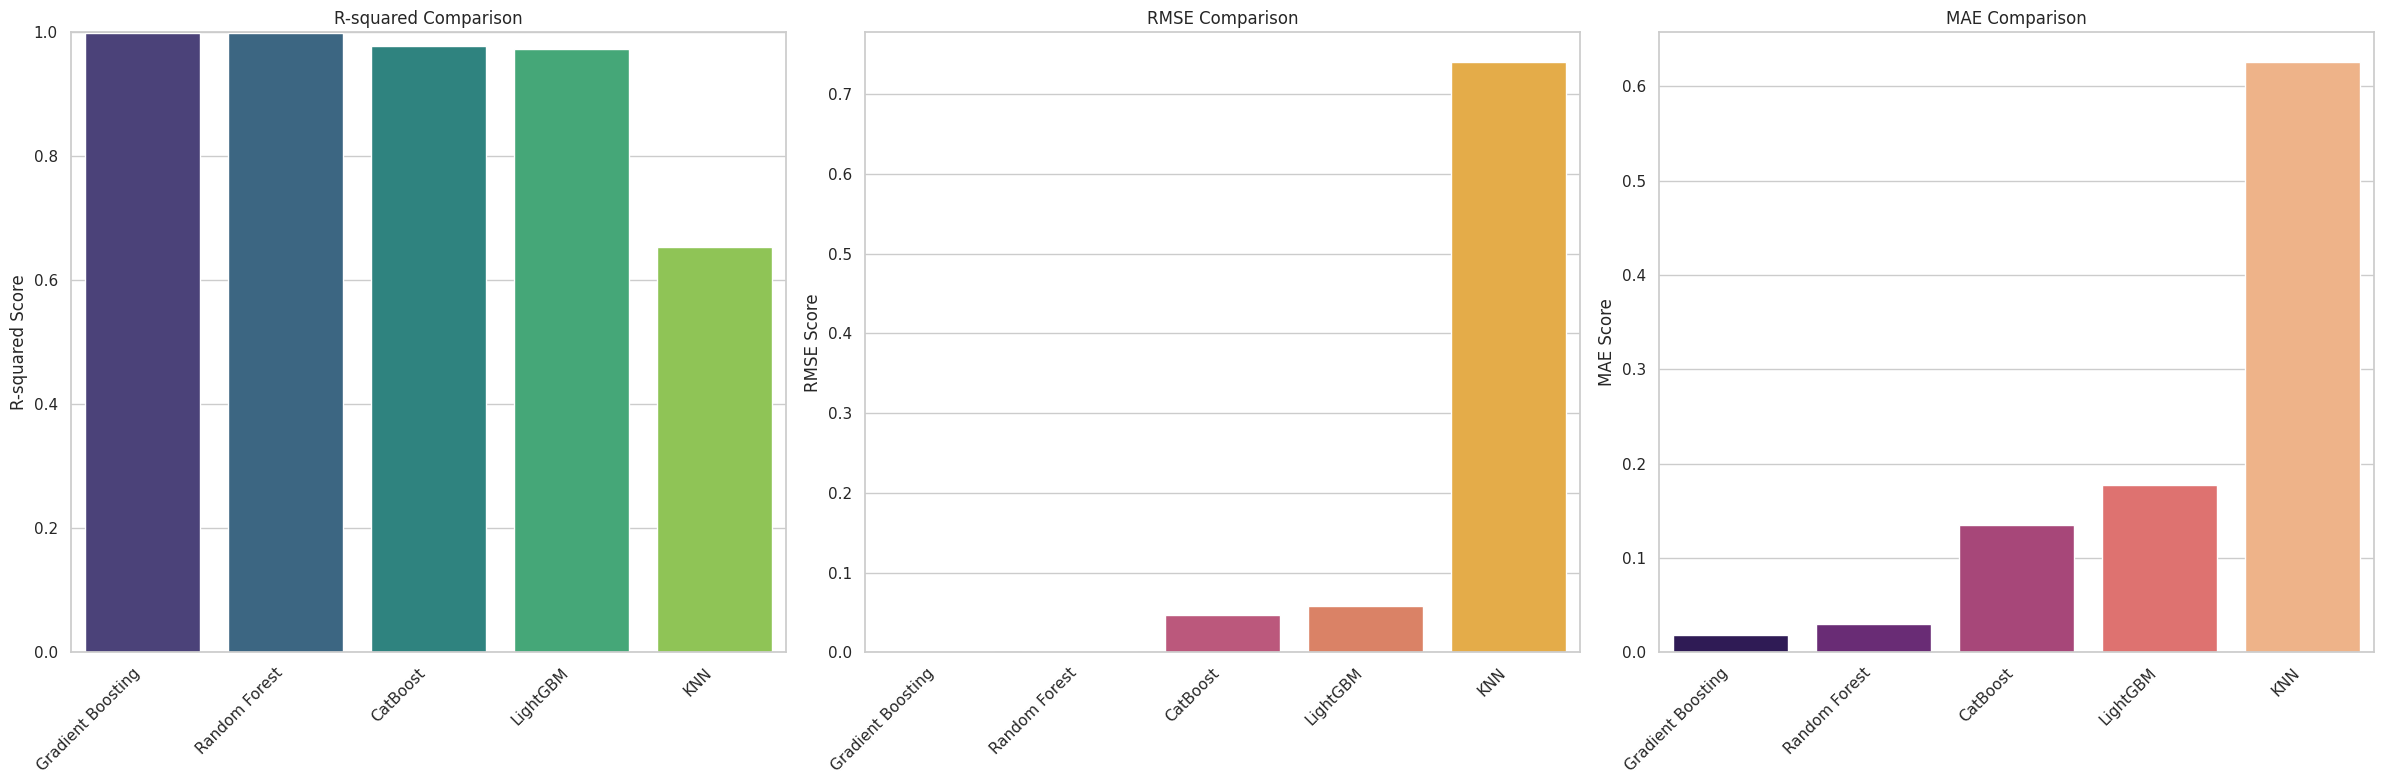

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Create a dictionary to store the metrics for each model
model_names = ['Random Forest', 'Gradient Boosting', 'LightGBM', 'CatBoost', 'KNN']
r2_scores = [r2_rf, r2_gbr, r2_lgb, r2_cb, r2_knn]
rmse_scores = [rmse_rf, rmse_gbr, rmse_lgb, rmse_cb, rmse_knn]
mae_scores = [mae_rf, mae_gbr, mae_lgb, mae_cb, mae_knn]

metrics_df = pd.DataFrame({
    'Model': model_names,
    'R-squared': r2_scores,
    'RMSE': rmse_scores,
    'MAE': mae_scores
})

metrics_df = metrics_df.sort_values(by='R-squared', ascending=False).reset_index(drop=True)

display(metrics_df)

# Set style for plots
sns.set_style("whitegrid")
plt.figure(figsize=(24, 8)) # Increased figure size for bigger plots

# Bar chart for R-squared
plt.subplot(1, 3, 1) # 1 row, 3 columns, 1st plot
sns.barplot(x='Model', y='R-squared', data=metrics_df, palette='viridis', hue='Model', legend=False)
plt.title('R-squared Comparison')
plt.xlabel('')
plt.ylabel('R-squared Score')
plt.ylim(0,1) # Changed to ylim for vertical bars
plt.xticks(rotation=45, ha='right') # Rotate x-axis labels

# Bar chart for RMSE
plt.subplot(1, 3, 2) # 1 row, 3 columns, 2nd plot
sns.barplot(x='Model', y='RMSE', data=metrics_df.sort_values(by='RMSE', ascending=True), palette='plasma', hue='Model', legend=False)
plt.title('RMSE Comparison')
plt.xlabel('')
plt.ylabel('RMSE Score')
plt.xticks(rotation=45, ha='right') # Rotate x-axis labels

# Bar chart for MAE
plt.subplot(1, 3, 3) # 1 row, 3 columns, 3rd plot
sns.barplot(x='Model', y='MAE', data=metrics_df.sort_values(by='MAE', ascending=True), palette='magma', hue='Model', legend=False)
plt.title('MAE Comparison')
plt.xlabel('')
plt.ylabel('MAE Score')
plt.xticks(rotation=45, ha='right') # Rotate x-axis labels

plt.tight_layout()
plt.show()